In [ ]:
!pip install -U tensorflow keras


## Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
import os

from sklearn.model_selection import train_test_split

os.environ["KERAS_BACKEND"] = "tensorflow"
keras.utils.set_random_seed(42)

In [ ]:
# Not needed because we are using a public RoBERTa model
# from huggingface_hub import login
# from google.colab import userdata

# HF_TOKEN = userdata.get('HF_TOKEN') # Access the saved secret
# if HF_TOKEN:
#     login(token=HF_TOKEN)
#     print("Successfully logged in to Hugging Face!")
# else:
#     print("HF_TOKEN not set in Colab secrets.")

## Load Dataset

In [ ]:
!pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eshummalik/socialbuzz-sentiment-analytics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'socialbuzz-sentiment-analytics' dataset.
Path to dataset files: /kaggle/input/socialbuzz-sentiment-analytics


In [ ]:
files = os.listdir(path)
print("Files found:", files)

Files found: ['sentimentdataset.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "sentimentdataset.csv"))

print(df.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

## Demoji and Tokenize

In [ ]:
!pip install demoji

import demoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.4 MB/s eta 0:00:00


In [ ]:
df['cleaned_text'] = df['Text'].apply(lambda x: demoji.replace(x, "")) # without emoji
df['replaced_text'] = df['Text'].apply(lambda x: demoji.replace_with_desc(x)) # textualised emoji
df['Emoji'] =  df['Text'].apply(lambda x: list(demoji.findall(x).values()))

## df['Likes'].min() -> 10.0, df['Likes'].max() -> 80.0
df['Likes'] = df['Likes'].apply(lambda x: 'High' if x > 59 else 'Low')

df = df[['Likes', 'cleaned_text', 'replaced_text', 'Emoji']]

df.head()

,Likes,cleaned_text,replaced_text,Emoji
0,Low,Enjoying a beautiful day at the park! ...,Enjoying a beautiful day at the park! ...,[]
1,Low,Traffic was terrible this morning. ...,Traffic was terrible this morning. ...,[]
2,Low,Just finished an amazing workout! ...,Just finished an amazing workout! :flexed bic...,[flexed biceps]
3,Low,Excited about the upcoming weekend getaway! ...,Excited about the upcoming weekend getaway! ...,[]
4,Low,Trying out a new recipe for dinner tonight. ...,Trying out a new recipe for dinner tonight. ...,[]


In [ ]:
df.shape

(732, 4)

## Load the model and tokenizer

In [ ]:
!pip install transformers==4.40.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 136.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

In [ ]:
from transformers import AutoTokenizer, AutoConfig
from transformers import TFRobertaModel

MODEL = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)

backbone = TFRobertaModel.from_pretrained(MODEL)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/499M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFRobertaModel.

All the layers of TFRobertaModel were initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


In [ ]:
def preprocess(text):
    new_text = []
    for t in str(text).split(" "): # Added str() just in case of NaNs
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

df['cleaned_text'] = df['cleaned_text'].apply(preprocess)
df['replaced_text'] = df['replaced_text'].apply(preprocess)

# Tokenize 'cleaned_text' and store in DF

clean_encodings = tokenizer(df['cleaned_text'].tolist(), padding=True, truncation=True, return_tensors='pt')
df['cleaned_input_ids'] = list(clean_encodings['input_ids'])
df['cleaned_attention_mask'] = list(clean_encodings['attention_mask'])

# Tokenize 'replaced_text' and store in DF
replaced_encodings = tokenizer(df['replaced_text'].tolist(), padding=True, truncation=True, return_tensors='pt')
df['replaced_input_ids'] = list(replaced_encodings['input_ids'])
df['replaced_attention_mask'] = list(replaced_encodings['attention_mask'])

labels = (df["Likes"] == "High").astype(int).values

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
cleaned_df = df[['cleaned_text', 'cleaned_input_ids', 'cleaned_attention_mask', 'Likes']]
replaced_df = df[['replaced_text', 'replaced_input_ids', 'replaced_attention_mask', 'Likes']]

cleaned_df.head()

,cleaned_text,cleaned_input_ids,cleaned_attention_mask,Likes
0,Enjoying a beautiful day at the park! ...,"[tensor(0), tensor(16013), tensor(154), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
1,Traffic was terrible this morning. ...,"[tensor(0), tensor(11830), tensor(21), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
2,Just finished an amazing workout! ...,"[tensor(0), tensor(1801), tensor(1550), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
3,Excited about the upcoming weekend getaway! ...,"[tensor(0), tensor(22847), tensor(4560), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
4,Trying out a new recipe for dinner tonight. ...,"[tensor(0), tensor(28386), tensor(66), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


## Split Dataset

In [ ]:
# Statified by "Likes" (binary: 1,0)
labels = (df["Likes"] == "High").astype(int)

# Train set index
train_idx, temp_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Validation set index + Test set index
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=labels[temp_idx],
    random_state=42
)


# cleaned_df dataset
c_train_df = cleaned_df.loc[train_idx]
c_val_df   = cleaned_df.loc[val_idx]
c_test_df  = cleaned_df.loc[test_idx]

# replaced_df dataset
r_train_df = replaced_df.loc[train_idx]
r_val_df   = replaced_df.loc[val_idx]
r_test_df  = replaced_df.loc[test_idx]

# labels
y_train = labels.loc[train_idx].values
y_val   = labels.loc[val_idx].values
y_test  = labels.loc[test_idx].values

In [ ]:
c_train_df.head()

,cleaned_text,cleaned_input_ids,cleaned_attention_mask,Likes
490,Standing before the grandeur of the Eiffel Tow...,"[tensor(0), tensor(45150), tensor(137), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
155,Empowerment through learning a new skill. ...,"[tensor(0), tensor(3676), tensor(11017), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
341,Curiosity sparked by exploring a mysterious an...,"[tensor(0), tensor(42090), tensor(45226), tens...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
527,"Rocking out at a Guns N' Roses show, the iconi...","[tensor(0), tensor(500), tensor(12088), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
137,The euphoria of a surprise birthday celebrati...,"[tensor(0), tensor(20), tensor(30882), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


In [ ]:
r_train_df.head()

,replaced_text,replaced_input_ids,replaced_attention_mask,Likes
490,Standing before the grandeur of the Eiffel Tow...,"[tensor(0), tensor(45150), tensor(137), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
155,Empowerment through learning a new skill. ...,"[tensor(0), tensor(3676), tensor(11017), tenso...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
341,Curiosity sparked by exploring a mysterious an...,"[tensor(0), tensor(42090), tensor(45226), tens...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
527,"Rocking out at a Guns N' Roses show, the iconi...","[tensor(0), tensor(500), tensor(12088), tensor...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low
137,The euphoria of a surprise birthday celebrati...,"[tensor(0), tensor(20), tensor(30882), tensor(...","[tensor(1), tensor(1), tensor(1), tensor(1), t...",Low


## Load a Pre-Trained Model

## Finetuning

In [ ]:
# # Compute weights to correct imbalanced dataset
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# classes = np.unique(y_train)

# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=y_train
# )

# class_weights = dict(zip(classes, weights))
# print(class_weights)

In [ ]:
import keras_hub

In [ ]:
# Check the actual lengths of tokenized rows

# cleaned
lengths = [len(x) for x in df['cleaned_input_ids']]
print(f"Max length in your data: {max(lengths)}")
print(f"Average length: {sum(lengths)/len(lengths)}")

# replaced
lengths = [len(x) for x in df['replaced_input_ids']]
print(f"Max length in your data: {max(lengths)}")
print(f"Average length: {sum(lengths)/len(lengths)}")

Max length in your data: 41
Average length: 41.0
Max length in your data: 41
Average length: 41.0


In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


In [ ]:
class RobertaLayer(keras.layers.Layer):
    def __init__(self, backbone, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            training=False
        )
        return outputs.last_hidden_state[:, 0, :]

In [ ]:
import keras_tuner as kt

def build_model(hp):
    # Define hyper-parameters
    units    = hp.Choice('units', values=[32, 64, 128])
    dropout  = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    lr       = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

    backbone.trainable = True

    input_ids      = keras.layers.Input(shape=(41,), dtype=tf.int32, name="input_ids")
    attention_mask = keras.layers.Input(shape=(41,), dtype=tf.int32, name="attention_mask")

    cls_output = RobertaLayer(backbone)([input_ids, attention_mask])

    x   = keras.layers.Dense(units, activation='relu')(cls_output)
    x   = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[input_ids, attention_mask], outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# GridSearch
tuner_C = kt.GridSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=None,
    directory='my_dir_C',
    project_name='keras_grid_search_C'
)

In [ ]:
### MODEL 1: Without Emoji
# Prepare data for cleaned
x_train_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_train_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_train_df["cleaned_attention_mask"]], dtype=tf.int32)
}
x_val_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_val_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_val_df["cleaned_attention_mask"]], dtype=tf.int32)
}

tuner_C.search(
    x=x_train_C,
    y=y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_C, y_val)
)

# Check best parameters
best_hp = tuner_C.get_best_hyperparameters(1)[0]
print("Best units:", best_hp.get('units'))
print("Best dropout:", best_hp.get('dropout'))
print("Best lr:", best_hp.get('learning_rate'))

Trial 27 Complete [00h 00m 42s]
val_accuracy: 0.8493150472640991

Best val_accuracy So Far: 0.8493150472640991
Total elapsed time: 00h 17m 49s
Best units: 32
Best dropout: 0.1
Best lr: 0.001


In [ ]:
# Make the best model
cleaned_best_model = tuner_C.get_best_models(num_models=1)[0]

#fit
historyC = cleaned_best_model.fit(
    x_train_C,
    y_train,
    validation_data=(x_val_C, y_val),
    epochs=5,
    batch_size=32
)

# Prepare test data
x_test_C = {
    "input_ids":      tf.constant([t.numpy() for t in c_test_df["cleaned_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in c_test_df["cleaned_attention_mask"]], dtype=tf.int32)
}

# Evaluate
loss, accuracy = cleaned_best_model.evaluate(x_test_C, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Estimate
predictions = cleaned_best_model.predict(x_test_C)
pred_labels = (predictions > 0.5).astype(int)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 774ms/step - accuracy: 0.8462 - loss: 0.4309 - val_accuracy: 0.8493 - val_loss: 0.4297
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8410 - loss: 0.4124 - val_accuracy: 0.8493 - val_loss: 0.4201
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8479 - loss: 0.4107 - val_accuracy: 0.8493 - val_loss: 0.3875
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8462 - loss: 0.3784 - val_accuracy: 0.8493 - val_loss: 0.3882
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8479 - loss: 0.3695 - val_accuracy: 0.8493 - val_loss: 0.3890
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8514 - loss: 0.4444
Test Loss: 0.4444
Test Accuracy: 0.8514
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


In [ ]:
cleaned_best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_layer       │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (RobertaLayer)      │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     24,608 │ roberta_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,925 (288.77 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 49,284 (192.52 KB)

**Note: The parameter count in model.summary() may show 0 for the backbone layer.
This is a known limitation of Keras 3.x, which cannot track weights of external TF models.
However, the backbone weights are still included in training and will be updated normally.

In [ ]:
### MODEL 2: Without Emoji
import keras_tuner as kt
# GridSearch
tuner_R = kt.GridSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=None,
    directory='my_dir_R',
    project_name='keras_grid_search_R'
)

# Prepare data for cleaned
x_train_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_train_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_train_df["replaced_attention_mask"]], dtype=tf.int32)
}
x_val_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_val_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_val_df["replaced_attention_mask"]], dtype=tf.int32)
}

tuner_R.search(
    x=x_train_R,
    y=y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_R, y_val)
)

# Check best parameters
best_hp = tuner_R.get_best_hyperparameters(1)[0]
print("Best units:", best_hp.get('units'))
print("Best dropout:", best_hp.get('dropout'))
print("Best lr:", best_hp.get('learning_rate'))

Trial 27 Complete [00h 00m 46s]
val_accuracy: 0.8493150472640991

Best val_accuracy So Far: 0.8630136847496033
Total elapsed time: 00h 19m 35s
Best units: 64
Best dropout: 0.1
Best lr: 1e-05


In [ ]:
# Make the best model
replaced_best_model = tuner_R.get_best_models(num_models=1)[0]

# Prepare test data
x_test_R = {
    "input_ids":      tf.constant([t.numpy() for t in r_test_df["replaced_input_ids"]], dtype=tf.int32),
    "attention_mask": tf.constant([t.numpy() for t in r_test_df["replaced_attention_mask"]], dtype=tf.int32)
}

#fit
historyR = replaced_best_model.fit(
    x_train_R,
    y_train,
    validation_data=(x_val_R, y_val),
    epochs=5,
    batch_size=32
)

# Evaluate
loss, accuracy = replaced_best_model.evaluate(x_test_R, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Estimate
predictions = replaced_best_model.predict(x_test_R)
pred_labels = (predictions > 0.5).astype(int)

Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 763ms/step - accuracy: 0.8256 - loss: 0.4704 - val_accuracy: 0.8630 - val_loss: 0.4331
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8376 - loss: 0.4344 - val_accuracy: 0.8493 - val_loss: 0.4230
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.8393 - loss: 0.4343 - val_accuracy: 0.8493 - val_loss: 0.4169
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.8376 - loss: 0.4412 - val_accuracy: 0.8493 - val_loss: 0.4134
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8410 - loss: 0.4333 - val_accuracy: 0.8493 - val_loss: 0.4108
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8514 - loss: 0.4258
Test Loss: 0.4258
Test Accuracy: 0.8514
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step


In [ ]:
replaced_best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_layer       │ (None, 768)       │          0 │ input_ids[0][0],  │
│ (RobertaLayer)      │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     49,216 │ roberta_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,845 (577.52 KB)

 Trainable params: 49,281 (192.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,564 (385.02 KB)

**Note: The parameter count in model.summary() may show 0 for the backbone layer.
This is a known limitation of Keras 3.x, which cannot track weights of external TF models.
However, the backbone weights are still included in training and will be updated normally.

Loss Curve

In [ ]:
# Function for plotting loss curve

def plot_loss(history, title):

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(train_loss)+1)

    plt.figure()

    plt.plot(epochs, train_loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Cross Entropy Loss")

    plt.legend()
    plt.show()

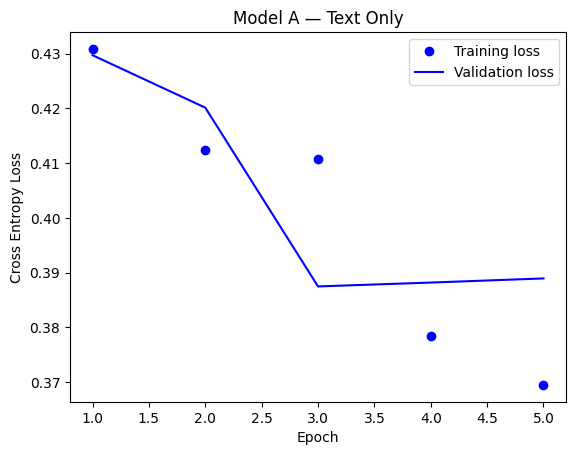

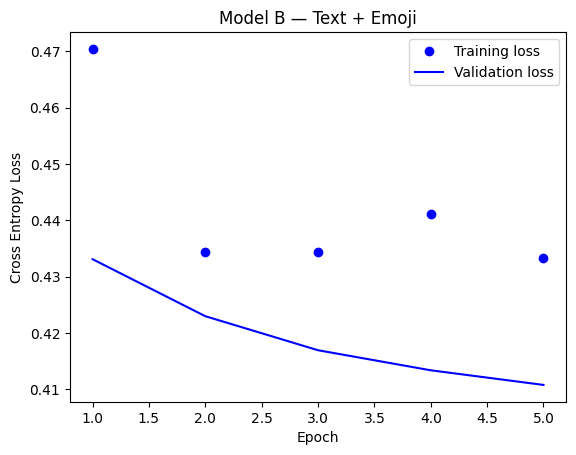

In [ ]:
plot_loss(historyC, "Model A — Text Only")
plot_loss(historyR, "Model B — Text + Emoji")

## Predictions

In [ ]:
# predict
y_prob_C = cleaned_best_model.predict(x_test_C)
y_pred_C = (y_prob_C > 0.5).astype(int)

# evaluate
cleaned_best_model.evaluate(x_train_C, y_train)
cleaned_best_model.evaluate(x_test_C, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8462 - loss: 0.3520
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8514 - loss: 0.4444


[0.4443517029285431, 0.8513513803482056]

In [ ]:
# predict
y_prob_R = replaced_best_model.predict(x_test_R)
y_pred_R = (y_prob_R > 0.5).astype(int)

# evaluate
replaced_best_model.evaluate(x_train_R, y_train)
replaced_best_model.evaluate(x_test_R, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8462 - loss: 0.4203
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8514 - loss: 0.4258


[0.42580386996269226, 0.8513513803482056]

## Evaluation metrics

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

f1_C = f1_score(y_test, y_pred_C)
roc_C = roc_auc_score(y_test, y_prob_C)

print("Cleaned Model")
print("F1-score:", f1_C)
print("ROC-AUC:", roc_C)

print("\nClassification Report")
print(classification_report(y_test, y_pred_C, target_names=["Low", "High"]))

Cleaned Model
F1-score: 0.0
ROC-AUC: 0.5613275613275615

Classification Report
              precision    recall  f1-score   support

         Low       0.85      1.00      0.92        63
        High       0.00      0.00      0.00        11

    accuracy                           0.85        74
   macro avg       0.43      0.50      0.46        74
weighted avg       0.72      0.85      0.78        74



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

f1_R = f1_score(y_test, y_pred_R)
roc_R = roc_auc_score(y_test, y_prob_R)

print("Cleaned Model")
print("F1-score:", f1_R)
print("ROC-AUC:", roc_R)

print("\nClassification Report")
# correct: y_pred_R
print(classification_report(y_test, y_pred_R, target_names=["Low", "High"]))

Cleaned Model
F1-score: 0.0
ROC-AUC: 0.5468975468975468

Classification Report
              precision    recall  f1-score   support

         Low       0.85      1.00      0.92        63
        High       0.00      0.00      0.00        11

    accuracy                           0.85        74
   macro avg       0.43      0.50      0.46        74
weighted avg       0.72      0.85      0.78        74



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = pd.DataFrame({

    "Model": ["Text Only", "Text + Emoji"],

    "F1 Score": [f1_C, f1_R],

    "ROC-AUC": [roc_C, roc_R]

})

results

,Model,F1 Score,ROC-AUC
0,Text Only,0.0,0.561328
1,Text + Emoji,0.0,0.546898


## Confusion Matrix

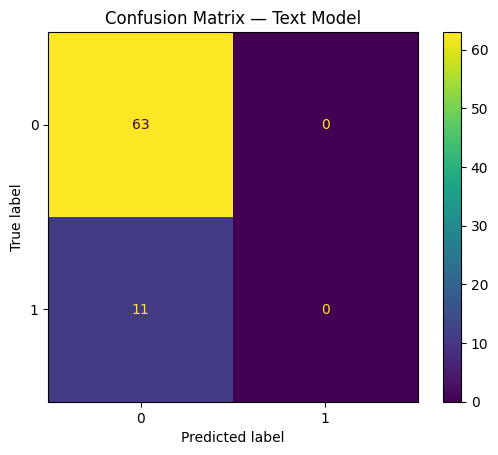

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_C
)

plt.title("Confusion Matrix — Text Model")
plt.show()

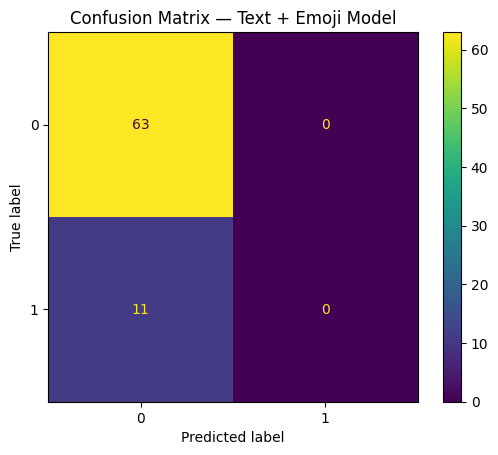

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_R
)

plt.title("Confusion Matrix — Text + Emoji Model")
plt.show()

## SHAP explanation

In [ ]:
import shap

def predict_fn(texts):
    encoded = tokenizer(
        list(texts),
        max_length=41,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    probs = cleaned_best_model.predict({
        "input_ids":      encoded["input_ids"],
        "attention_mask": encoded["attention_mask"]
    })
    return probs  # shape (N, 1)

explainer_C = shap.Explainer(
    predict_fn,
    shap.maskers.Text(tokenizer)
)

# train 텍스트 원본으로 넘기기
shap_values_C = explainer_C(list(c_train_df["cleaned_text"])[:20])

shap.plots.text(shap_values_C[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━

...

PartitionExplainer explainer: 100%|██████████| 20/20 [02:44<00:00,  8.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer: 21it [02:53,  8.66s/it]


In [ ]:
def predict_fn_replaced(texts):
    encoded = tokenizer(
        list(texts),
        max_length=41,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    probs = replaced_best_model.predict({
        "input_ids":      encoded["input_ids"],
        "attention_mask": encoded["attention_mask"]
    })
    return probs

explainer_R = shap.Explainer(
    predict_fn_replaced,
    shap.maskers.Text(tokenizer)
)

shap_values_R = explainer_R(list(r_train_df["replaced_text"])[:20])

shap.plots.text(shap_values_R[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

...

PartitionExplainer explainer: 100%|██████████| 20/20 [02:41<00:00,  8.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

  0%|          | 0/498 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

PartitionExplainer explainer: 21it [02:50,  8.52s/it]
